# Install and Import necessary libraries

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold


# Upload Cytotoxicity Data and Create DataFrame

In [2]:
# Load Dataset
model = 'cytotoxicity_data'
df = pd.read_csv(f'{model}.csv')

In [3]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (440, 69)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_use', 'addtive3_name', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'cell_line', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'dilution_medium', 'concentration', 'concentration_units', 'dilution', 'incubation_time', 'incubation_time_units', 'incubation_temperature', 'incubation_temperature_units', 'co2_percentage', 'air', 'extraction_time', 'units_extraction_time', 'extraction_temperature', 'units_extraction_t', 'extraction_medium', 'extraction_surface_area_ratio', 'extraction_sur

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [4]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'addtive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'ic_50_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (440, 43)


In [5]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','ic_50', 'growth_constant_μ', 'rgr',
              'toxicity_grade','zone_index','lysis_index', 'growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 35)


In [6]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type', # derived from cell_line
                  # 'polymer_percentage' # =100-(additive1+additive2+additive3)percentage, it can be omitted as well
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 33)


# Train/Test Split

In [7]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (11):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - air
  - extraction_medium


In [8]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [9]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (330, 32) class proportions toxicity
non-toxic    253
toxic         77
Name: count, dtype: int64

Test size (83, 32) class proportions toxicity
non-toxic    64
toxic        19
Name: count, dtype: int64


In [10]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 330



,Missing Values,Missing Percentage (%)
surface,326,98.8
number_of_cells_well,319,96.7
extraction_medium,309,93.6
extraction_time,309,93.6
extraction_temperature,303,91.8
extraction_surface_area_ratio,294,89.1
diameter,286,86.7
thickness,272,82.4
dilution,267,80.9
pdi,262,79.4


In [11]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (109, 15) class proportions toxicity
non-toxic    86
toxic        23
Name: count, dtype: int64

Test size (27, 15) class proportions toxicity
non-toxic    21
toxic         6
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [12]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    109.000000
mean      93.256881
std        6.796518
min       85.000000
25%       88.000000
50%       88.000000
75%      100.000000
max      100.000000
Name: hb_ratio, dtype: float64


count    109.000000
mean      28.812569
std       14.584613
min        0.000000
25%       23.000000
50%       32.900000
75%       33.330000
max       90.000000
Name: additive1_percentage, dtype: float64


count    109.000000
mean      26.464404
std       17.222337
min        0.000000
25%        0.000000
50%       32.900000
75%       33.330000
max       55.000000
Name: additive2_percentage, dtype: float64


count    109.000000
mean       4.691009
std        8.892202
min        0.000000
25%        0.000000
50%        0.000000
75%        1.320000
max       32.000000
Name: additive3_percentage, dtype: float64


count    109.000000
mean      39.145596
std       27.936167
min        6.000000
25%       11.000000
50%       32.900000
75%       33.330000
max      100.000000
Name: polymer_percentage, dtyp

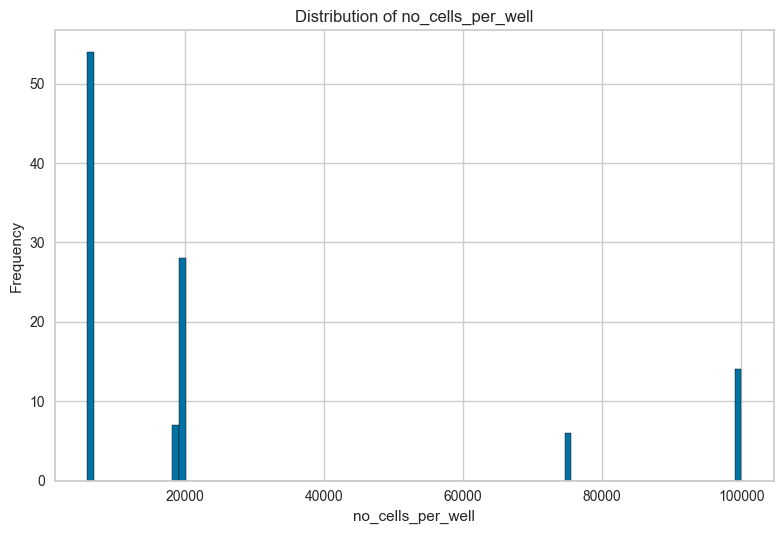



no_cells_per_well
6000.0      54
19000.0      7
20000.0     28
75000.0      6
100000.0    14
Name: count, dtype: int64


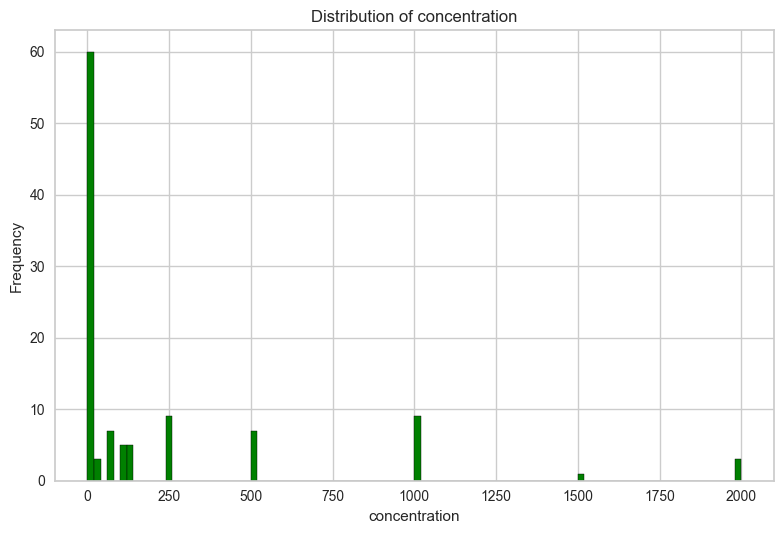



concentration
0.00       10
0.20        9
0.60        6
1.00        2
1.30        8
3.00       10
6.00       11
10.00       2
15.60       2
31.25       3
62.50       7
100.00      5
125.00      5
250.00      9
500.00      7
1000.00     9
1500.00     1
2000.00     3
Name: count, dtype: int64


In [13]:
# Check heavily skewed features (high value of std)

## Plot a histogram of the distribution of no_cells_per_well
X_train['no_cells_per_well'].hist(bins=100, edgecolor='black')
plt.xlabel('no_cells_per_well')
plt.ylabel('Frequency')
plt.title('Distribution of no_cells_per_well')
plt.tight_layout()
# plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of no_cells_per_well
print('\n')
print(X_train['no_cells_per_well'].value_counts().sort_index())

## Plot a histogram of the distribution of concentration
X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
plt.xlabel('concentration')
plt.ylabel('Frequency')
plt.title('Distribution of concentration')
plt.tight_layout()
# plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of concentration
print('\n')
print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [14]:
# Categorise no_cells_per_wel feature
bins = [0, 10_000, 50_000, float('inf')]
labels = ['low', 'medium', 'high']

X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

Train set: no_cells_per_well
low       54
medium    35
high      20
Name: count, dtype: int64
Test set: no_cells_per_well
low       18
medium     8
high       1
Name: count, dtype: int64


In [15]:
# Categorise concetration
bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['concentration'].value_counts()}")
print(f"\nTest set: {X_test['concentration'].value_counts()}")

Train set: concentration
very_low     25
low          21
very_high    20
high         19
medium       14
zero         10
Name: count, dtype: int64

Test set: concentration
very_low     13
medium        4
low           3
very_high     3
zero          2
high          2
Name: count, dtype: int64


## Outlier Detection

In [16]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


## Handle Categorical Features

In [17]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X



cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

# Drop columns with only one category after transformations (fit on train only)
cols_to_drop = [col for col in cat_cols if X_train_clean[col].nunique() <= 1]
X_train_clean = X_train_clean.drop(columns=cols_to_drop)
X_test_clean = X_test_clean.drop(columns=cols_to_drop)
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
print(f"{cols_to_drop} has only 1 category and has been dropped from train set")

[shape] 'other' has only 1 rows → merging into 'tetra_arm_star'
[culture_medium] 'other' has only 3 rows → merging into 'dmem_fbs_p/s'
[] has only 1 category and has been dropped from train set


In [18]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



no_cells_per_well
low       54
medium    35
high      20
Name: count, dtype: int64


concentration
very_low     25
low          21
very_high    20
high         19
medium       14
zero         10
Name: count, dtype: int64


shape
nanospheres       54
microsphere       20
diblock_star      18
nanoparticle      10
tetra_arm_star     7
Name: count, dtype: int64


additive1_use
targeting_ligand    54
responsive          25
filler              10
not_applicable       7
anticancer           7
other                6
Name: count, dtype: int64


additive2_use
stabilizer        54
not_applicable    30
stealth           25
Name: count, dtype: int64


additive3_use
not_applicable    58
active_drug       26
hydrophobe        25
Name: count, dtype: int64


assay
mtt        89
diic1_5    14
mts         6
Name: count, dtype: int64


cell_line
mcf7          54
ccd_112con    25
jurkat        11
a549           7
hepg2          6
other          6
Name: count, dtype: int64


culture_medium
dmem_10fbs_pen_

In [19]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 109 rows | Test: 27 rows


# Feature Selection 

In [20]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (9):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


## Mutual Information 

In [21]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)

Mutual Information Scores:
additive1_percentage    0.315861
polymer_percentage      0.301795
additive1_use           0.196738
cell_line               0.182172
additive2_percentage    0.177036
additive3_percentage    0.162405
culture_medium          0.159840
shape                   0.149442
additive3_use           0.121013
hb_ratio                0.070957
additive2_use           0.063648
concentration           0.057891
incubation_time         0.038127
assay                   0.033872
no_cells_per_well       0.022745
dtype: float64


## Kendal correlation (Num vs Num)

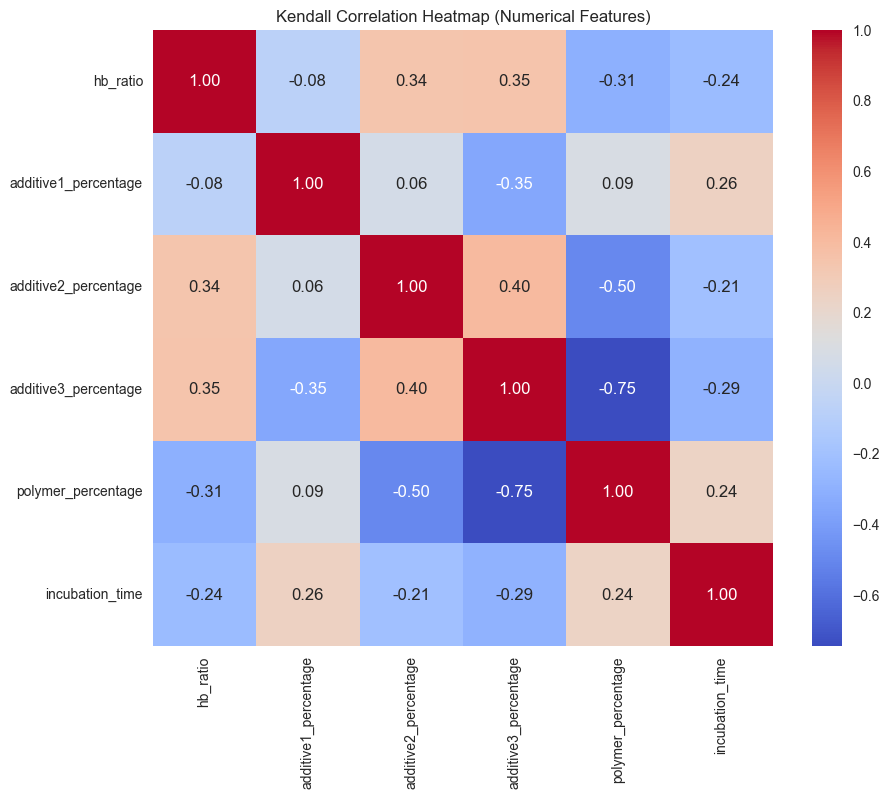

In [22]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
plt.show()

## Cramér's V (Cat vs Cat)

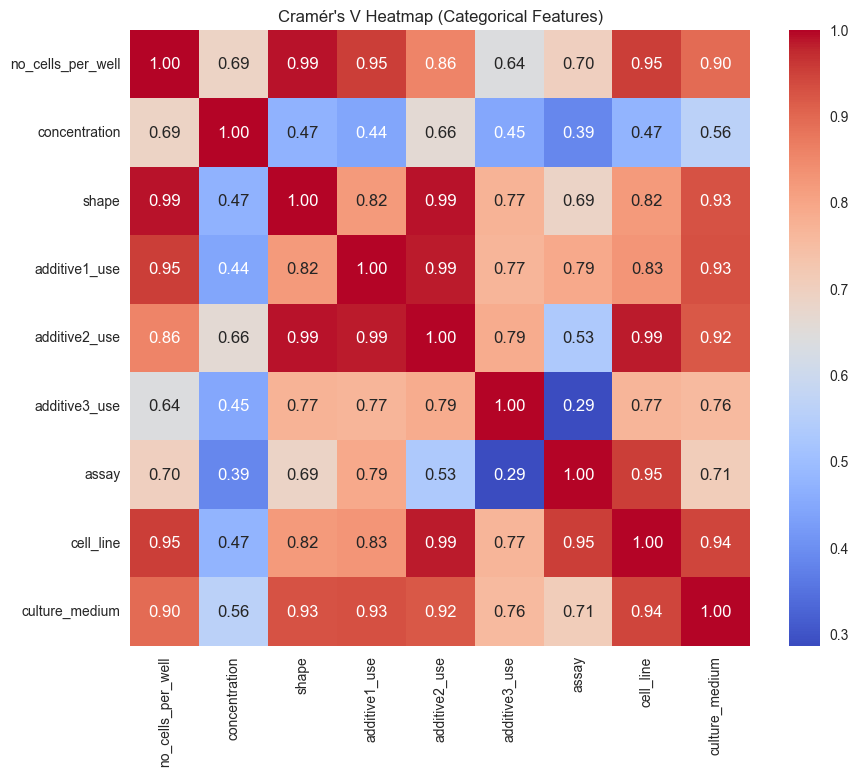

In [23]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [24]:
feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
X_train_clean = X_train_clean.drop(columns=feature_to_drop)
X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
print(f"Drop feature: {feature_to_drop}") 

Drop feature: no_cells_per_well


# Machine Learning Algorithm

In [25]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols 

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (8):
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


In [26]:
# Preprocessing pipeline
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)

# Fit the preprocessor on the training data and transform both train and test sets
X_train_preprocessed = pre.fit_transform(X_train_clean)
X_test_preprocessed  = pre.transform(X_test_clean)

# Label encode the target variable for PyCaret and convert to DataFrame for easier handling ('Non_Toxic' -> 0, 'Toxic' -> 1)
label_encoder = LabelEncoder()
y_train_clean = pd.Series(label_encoder.fit_transform(y_train_clean), index=X_train_clean.index)
y_test_clean  = pd.Series(label_encoder.transform(y_test_clean), index=X_test_clean.index)    


# Get feature names after one-hot encoding
ohe_feature_names = pre.named_transformers_["cat"].get_feature_names_out(features_cat)
feature_names = features_num + list(ohe_feature_names)
print(f"Total features after preprocessing: {len(feature_names)}")

# Convert back to DataFrame for easier handling
X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names) 

# Join the target back to the preprocessed features for PyCaret
train_data = X_train_df.copy()
train_data[target] = y_train_clean.values

test_data = X_test_df.copy()
test_data[target] = y_test_clean.values


Total features after preprocessing: 42


In [ ]:
# --------------------------------------------------------------------------
# Applicability Domain (AD) check on the test set
# --------------------------------------------------------------------------

# Fit each DOA method on the training feature matrix (numpy array)
doa_methods = {
    "Leverage":    Leverage(),
    "BoundingBox": BoundingBox()
}

X_train_arr = train_data.drop(columns=[target]).values
X_test_arr  = test_data.drop(columns=[target]).values

# Build a per-method boolean mask of whether each test sample is IN domain
in_doa_per_method = {}
for name, method in doa_methods.items():
    method.fit(X_train_arr)
    preds = method.predict(X_test_arr)
    in_doa_per_method[name] = np.array([bool(p["inDoa"]) for p in preds])

# Combine into a DataFrame for inspection
ad_df = pd.DataFrame(in_doa_per_method, index=X_test_df.index)
ad_df["votes_in"]  = ad_df.sum(axis=1)              # number of methods saying IN
ad_df["votes_out"] = len(doa_methods) - ad_df["votes_in"]
# Majority rule: sample is IN domain iff at least 2 of 3 methods say IN
ad_df["in_domain"] = ad_df["votes_in"] >= 2

print("Per-method in-domain counts (test set):")
for name in doa_methods:
    n_in  = int(ad_df[name].sum())
    n_out = int((~ad_df[name]).sum())
    print(f"  {name:<12}  in: {n_in:>3}   out: {n_out:>3}")

n_total   = len(ad_df)
n_in_maj  = int(ad_df["in_domain"].sum())
n_out_maj = n_total - n_in_maj
print(f"\nMajority vote (>=2/3 in-domain):")
print(f"  Test samples kept (in-domain):     {n_in_maj} / {n_total}")
print(f"  Test samples excluded (out-of-AD): {n_out_maj} / {n_total}")

# Build AD-filtered test set used for downstream evaluation
in_domain_mask = ad_df["in_domain"].values
X_test_df_ad      = X_test_df.loc[in_domain_mask].copy()
y_test_clean_ad   = y_test_clean.loc[X_test_df_ad.index].copy()

# DataFrame for PyCaret's predict_model (features + target column)
test_data_ad = X_test_df_ad.copy()
test_data_ad[target] = y_test_clean_ad.values

Per-method in-domain counts (test set):
  Leverage      in:  26   out:   1
  BoundingBox   in:  27   out:   0

Majority vote (>=2/3 in-domain):
  Test samples kept (in-domain):     26 / 27
  Test samples excluded (out-of-AD): 1 / 27


In [28]:
# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data_ad,
            target=target,
            preprocess=False,          # data already preprocessed
            fix_imbalance=True,
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
            index=False,
            session_id=42)

# Compare models and select the best one based on AUC
best_model = compare_models(sort='mcc', n_select=1)
print(f"Best model: {best_model}")

,Description,Value
0,Session id,42
1,Target,toxicity
2,Target type,Binary
3,Original data shape,"(135, 43)"
4,Transformed data shape,"(135, 43)"
5,Transformed train set shape,"(109, 43)"
6,Transformed test set shape,"(26, 43)"
7,Numeric features,42


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9109,0.9561,0.7800,0.8197,0.7863,0.7308,0.7405,0.0896
et,Extra Trees Classifier,0.9100,0.8745,0.7930,0.7977,0.7863,0.7298,0.7366,0.0100
lr,Logistic Regression,0.9109,0.9360,0.7200,0.8609,0.7690,0.7156,0.7294,0.0632
ridge,Ridge Classifier,0.9018,0.9282,0.8000,0.7825,0.7776,0.7159,0.7261,0.0018
rf,Random Forest Classifier,0.9072,0.9465,0.7510,0.8129,0.7706,0.7132,0.7211,0.0120
xgboost,Extreme Gradient Boosting,0.9018,0.9358,0.7550,0.8026,0.7622,0.7015,0.7130,0.0028
gbc,Gradient Boosting Classifier,0.8981,0.9370,0.7660,0.7725,0.7571,0.6936,0.7016,0.0044
ada,Ada Boost Classifier,0.8926,0.9356,0.7730,0.7583,0.7494,0.6824,0.6936,0.0040
lda,Linear Discriminant Analysis,0.8779,0.9144,0.8480,0.6878,0.7479,0.6708,0.6861,0.0014
dt,Decision Tree Classifier,0.8926,0.8671,0.7350,0.7779,0.7379,0.6718,0.6839,0.0012


Best model: CatBoostClassifier(border_count=254, random_state=42, task_type='CPU', verbose=False)


In [29]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(best_model,
                         optimize='mcc',
                         search_library='optuna',
                         n_iter=50,
                         )
# Check the best hyperparameters found
best_params = tuned_model.get_params()
print("Best hyperparameters:", best_params)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.9444,0.5000,1.0000,0.6667,0.6207,0.6708
1,0.9091,0.8882,0.8000,0.8000,0.8000,0.7412,0.7412
2,0.9091,0.9941,1.0000,0.7143,0.8333,0.7732,0.7939
3,0.9545,0.9941,0.8000,1.0000,0.8889,0.8608,0.8692
4,0.9524,0.9853,1.0000,0.8000,0.8889,0.8591,0.8677
5,0.9091,0.9861,0.7500,0.7500,0.7500,0.6944,0.6944
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.8182,0.9118,1.0000,0.5556,0.7143,0.5963,0.6518
8,0.9091,0.9647,0.8000,0.8000,0.8000,0.7412,0.7412


Best hyperparameters: {'depth': 4, 'l2_leaf_reg': 52, 'border_count': 254, 'verbose': False, 'random_strength': 0.5073365203891752, 'task_type': 'CPU', 'n_estimators': 114, 'random_state': 42, 'eta': 0.10165546504034652}


In [30]:
predict_model(tuned_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.8846,0.9542,1.0000,0.6667,0.8000,0.7234,0.7528


,hb_ratio,additive1_percentage,additive2_percentage,additive3_percentage,polymer_percentage,incubation_time,concentration_high,concentration_low,concentration_medium,concentration_very_high,...,cell_line_jurkat,cell_line_mcf7,cell_line_other,culture_medium_dmem_10fbs_pen_strep,culture_medium_dmem_fbs_p/s,culture_medium_dmem_fp,culture_medium_rpmi-1640,toxicity,prediction_label,prediction_score
109,-0.777039,0.917333,-1.543730,-0.529979,0.673353,-0.859093,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0.7776
110,-1.220481,0.311170,0.400486,-0.529979,-0.209136,0.441478,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0,0.9736
111,-1.220481,0.281551,0.375403,-0.380848,-0.224599,0.441478,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1,0.7060
112,0.996726,0.311170,0.400486,-0.529979,-0.209136,1.742050,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0,0.9653
113,-1.220481,0.311170,0.400486,-0.529979,-0.209136,1.742050,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0,0.9646
114,-1.220481,0.281551,0.375403,-0.380848,-0.224599,1.742050,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1,0.7956
115,0.996726,0.281551,0.375403,-0.380848,-0.224599,0.441478,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,1,0.7021
116,-0.777039,-1.984671,-1.543730,-0.529979,2.188399,0.441478,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.9649
117,-1.220481,0.281551,0.375403,-0.380848,-0.224599,-0.859093,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0,0.8217
118,-1.220481,0.311170,0.400486,-0.529979,-0.209136,-0.859093,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0,0.9769


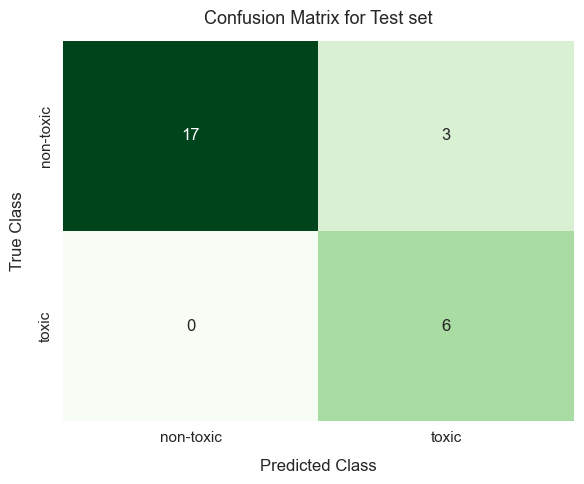

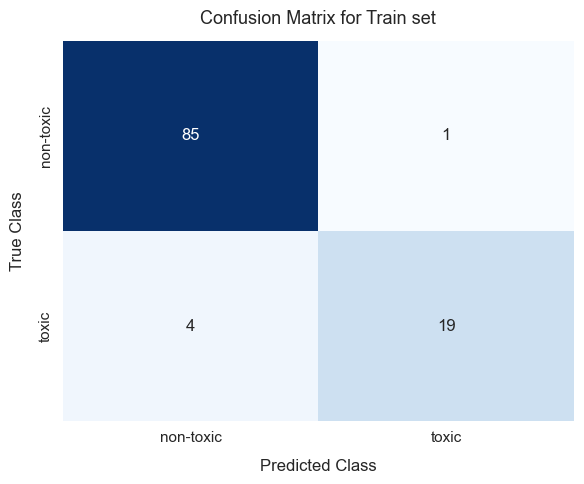

In [31]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = label_encoder.classes_
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    # plt.show()
    plt.show() 
# TEST SET
X_test_pred = tuned_model.predict(X_test_df_ad)
cm_test = confusion_matrix(y_test_clean_ad, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set', 'Greens') 
# TRAIN SET
X_train_pred = tuned_model.predict(X_train_df)
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set', 'Blues')

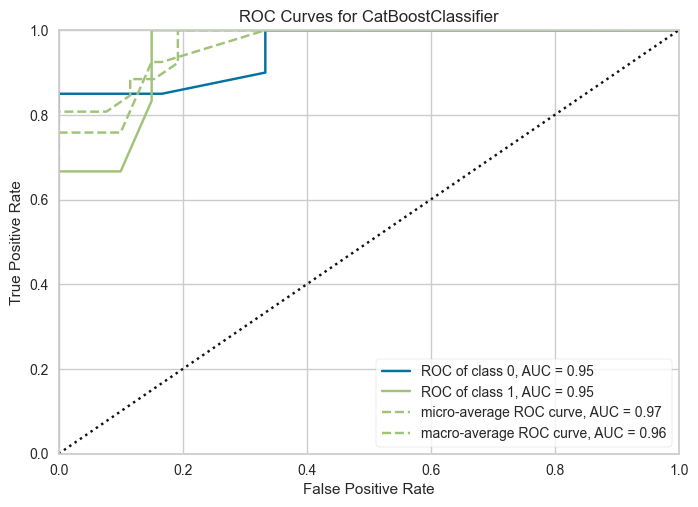

In [32]:
plot_model(tuned_model)

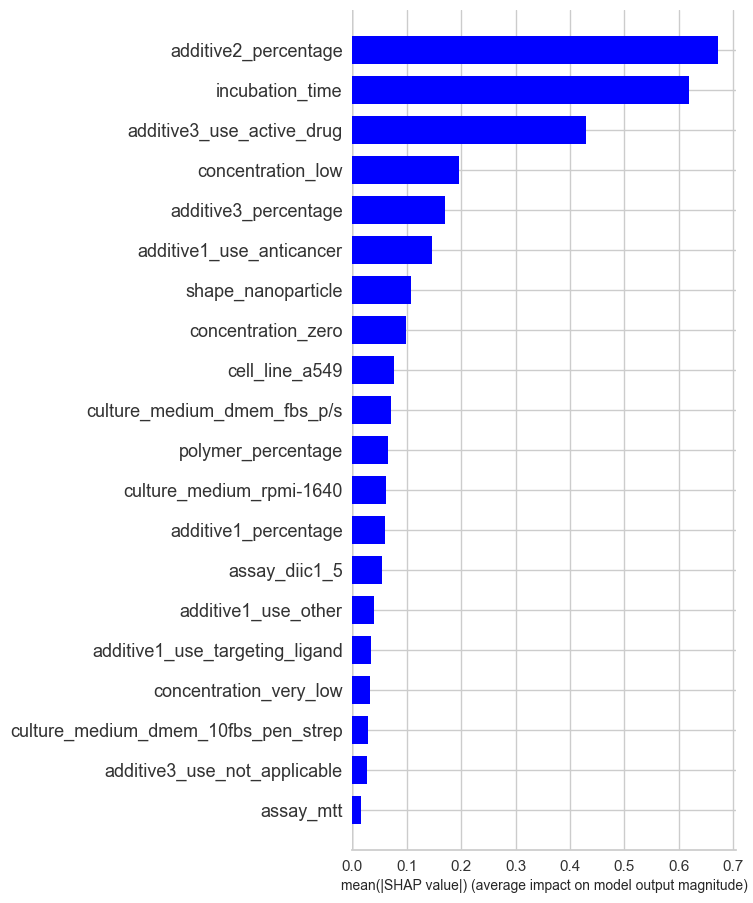

In [33]:
# Check SHAP values for the tuned model to understand feature importance and contribution to predictions
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_df)
fig, ax = plt.subplots(figsize=(12, 12))  # πιο φαρδύ figure
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, 
                  plot_type="bar", show=False, color='blue')
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=10)
plt.tight_layout(pad=2.0)
# plt.savefig('shap_summary_plot.png', dpi=600, bbox_inches='tight')
plt.show()

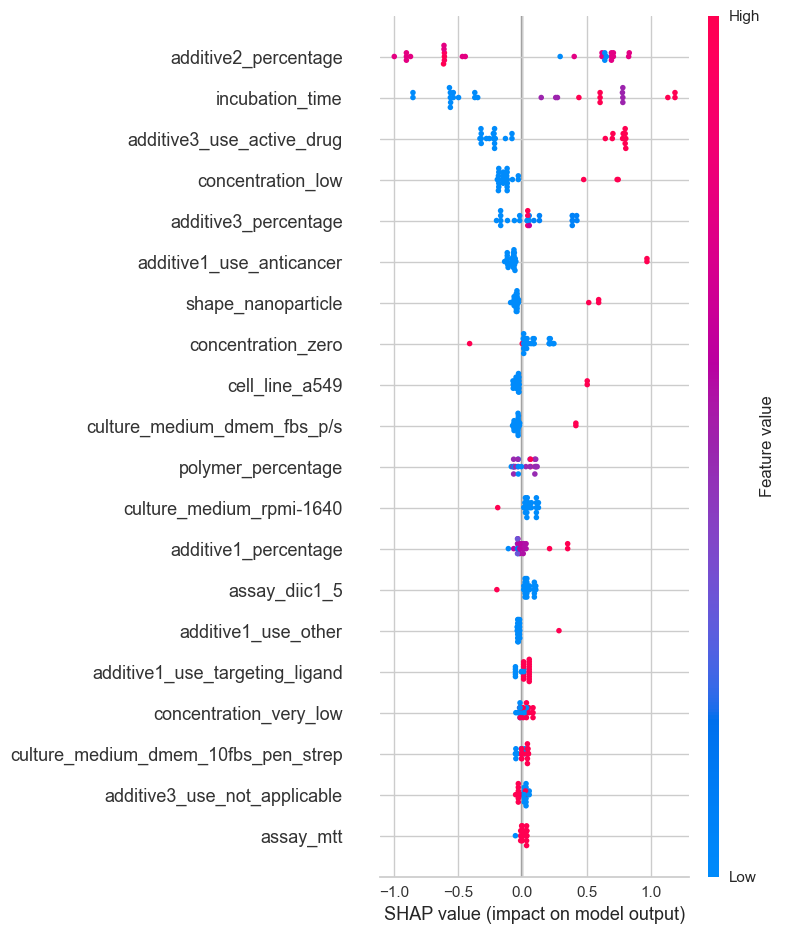

In [34]:
# Check SHAP tree explainers for the tuned model to understand feature interactions and contribution to predictions
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, plot_type="dot", show=False)
plt.tight_layout()
# plt.savefig('shap_summary_plot_dot.png', dpi=600, bbox_inches='tight')
plt.show()

# End of code


# Jacpotpy

In [35]:
# Set train dataset for jaqpot
train_dataset = JaqpotTabularDataset(
                                    df=train_data,
                                    x_cols=train_data.drop(columns=[target]).columns.to_list(),
                                    y_cols=target,
                                    task="BINARY_CLASSIFICATION",
)

# Set test dataset for jaqpot
test_dataset = JaqpotTabularDataset(
                                    df=test_data_ad,
                                    x_cols=test_data_ad.drop(columns=[target]).columns.to_list(),
                                    y_cols=target,
                                    task="BINARY_CLASSIFICATION",
)

In [52]:
JAQPOT_COMPATIBLE_CLASSIFIERS = [
    'AdaBoostClassifier',
    'BaggingClassifier',
    'BernoulliNB',
    'CalibratedClassifierCV',
    'CategoricalNB',
    'ComplementNB',
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GaussianNB',
    'GaussianProcessClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'KNeighborsClassifier',
    'LinearSVC',
    'LogisticRegression',       
    'MLPClassifier',
    'MultinomialNB',
    'OneVsOneClassifier',
    'OneVsRestClassifier',
    'QuadraticDiscriminantAnalysis',
    'RadiusNeighborsClassifier',
    'RandomForestClassifier',
    'SGDClassifier',
    'SVC',
    'StackingClassifier',
    'VotingClassifier',
    'RidgeClassifier',           
    'LinearDiscriminantAnalysis', 
]

# Compare models and get results
best_results = compare_models(sort='mcc', n_select=5)

# Check if any of the results is compatible
chosen_model = None
for m in best_results:
    if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS:
        chosen_model = m
        print(f"Found compatible model: {type(m).__name__}")
        break

# Tune the compatible model
print(f"\nTuning {type(chosen_model).__name__}...")
tuned_chosen = tune_model(chosen_model,
                          optimize='mcc',
                          search_library='optuna',
                          n_iter=50
                          )
final_model = type(tuned_chosen)(**tuned_chosen.get_params())
print("Tuning complete")

# Fit train data to jaqpot
jaqpot_model = SklearnModel(
                            dataset=train_dataset,
                            model=final_model,
                            doa=[Leverage(), BoundingBox(), MeanVar()],
    
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()
print("Jaqpot model ready")


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9109,0.9561,0.7800,0.8197,0.7863,0.7308,0.7405,0.0872
et,Extra Trees Classifier,0.9100,0.8745,0.7930,0.7977,0.7863,0.7298,0.7366,0.0114
lr,Logistic Regression,0.9109,0.9360,0.7200,0.8609,0.7690,0.7156,0.7294,0.0560
ridge,Ridge Classifier,0.9018,0.9282,0.8000,0.7825,0.7776,0.7159,0.7261,0.0014
rf,Random Forest Classifier,0.9072,0.9465,0.7510,0.8129,0.7706,0.7132,0.7211,0.0110
xgboost,Extreme Gradient Boosting,0.9018,0.9358,0.7550,0.8026,0.7622,0.7015,0.7130,0.0028
gbc,Gradient Boosting Classifier,0.8981,0.9370,0.7660,0.7725,0.7571,0.6936,0.7016,0.0044
ada,Ada Boost Classifier,0.8926,0.9356,0.7730,0.7583,0.7494,0.6824,0.6936,0.0042
lda,Linear Discriminant Analysis,0.8779,0.9144,0.8480,0.6878,0.7479,0.6708,0.6861,0.0012
dt,Decision Tree Classifier,0.8926,0.8671,0.7350,0.7779,0.7379,0.6718,0.6839,0.0012


Found compatible model: ExtraTreesClassifier

Tuning ExtraTreesClassifier...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8636,0.9306,0.7500,0.6000,0.6667,0.5823,0.5880
1,0.9091,0.9529,0.8000,0.8000,0.8000,0.7412,0.7412
2,0.9091,1.0000,1.0000,0.7143,0.8333,0.7732,0.7939
3,0.9545,0.9941,1.0000,0.8333,0.9091,0.8791,0.8856
4,0.9524,0.9853,1.0000,0.8000,0.8889,0.8591,0.8677
5,0.9545,0.9861,1.0000,0.8000,0.8889,0.8608,0.8692
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.9091,0.9588,1.0000,0.7143,0.8333,0.7732,0.7939
8,0.9545,0.9882,1.0000,0.8333,0.9091,0.8791,0.8856


Tuning complete
Goodness-of-fit metrics on training set:
{'accuracy': 0.944954128440367, 'balancedAccuracy': 0.949191102123357, 'precision': array([0.94186047, 0.95652174]), 'recall': array([0.98780488, 0.81481481]), 'f1Score': array([0.96428571, 0.88      ]), 'jaccard': array([0.93103448, 0.78571429]), 'matthewsCorrCoef': 0.8491520763953988, 'confusionMatrix': array([[81,  5],
       [ 1, 22]])}
Jaqpot model ready


In [53]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=5)

{'accuracy': 0.9173160173160173,
 'balancedAccuracy': 0.8684232026143791,
 'precision': array([0.94351307, 0.79333333]),
 'recall': array([0.95470588, 0.74      ]),
 'f1Score': array([0.94828877, 0.75545455]),
 'jaccard': array([0.9031746 , 0.63428571]),
 'matthewsCorrCoef': 0.7127088011890053,
 'confusionMatrix': array([[16.2,  1. ],
        [ 0.8,  3.8]])}

In [54]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'accuracy': 0.8846153846153846,
 'balancedAccuracy': 0.925,
 'precision': array([0.85, 1.  ]),
 'recall': array([1.        , 0.66666667]),
 'f1Score': array([0.91891892, 0.8       ]),
 'jaccard': array([0.85      , 0.66666667]),
 'matthewsCorrCoef': 0.7527726527090811,
 'confusionMatrix': array([[17,  3],
        [ 0,  6]])}

In [55]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'accuracy': 0.8899082568807339,
   'balancedAccuracy': 0.8506066734074823,
   'precision': array([0.91860465, 0.7826087 ]),
   'recall': array([0.94047619, 0.72      ]),
   'f1Score': array([0.92941176, 0.75      ]),
   'jaccard': array([0.86813187, 0.6       ]),
   'matthewsCorrCoef': 0.6805400208771029,
   'confusionMatrix': array([[79,  7],
          [ 5, 18]])},
  'Test': {'accuracy': 0.6153846153846154,
   'balancedAccuracy': 0.4,
   'precision': array([0.8, 0. ]),
   'recall': array([0.72727273, 0.        ]),
   'f1Score': array([0.76190476, 0.        ]),
   'jaccard': array([0.61538462, 0.        ]),
   'matthewsCorrCoef': -0.23354968324845687,
   'confusionMatrix': array([[16,  4],
          [ 6,  0]])}},
 'iteration_1': {'Train': {'accuracy': 0.8348623853211009,
   'balancedAccuracy': 0.8157229524772498,
   'precision': array([0.84883721, 0.7826087 ]),
   'recall': array([0.93589744, 0.58064516]),
   'f1Score': array([0.8902439 , 0.66666667]),
   'ja

In [57]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary


{'LEVERAGE': {'n_total': 26, 'n_in': 26, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 26, 'n_in': 26, 'n_out': 0}}

In [50]:
# # Upload the pretrained model on Jaqpot
# jaqpot = Jaqpot()
# jaqpot.login()
# jaqpot_model.deploy_on_jaqpot(
#     jaqpot=jaqpot,
#     name="Cytotoxicity_model_A.N.I.P.H.",
#     description="Predict cytotoxicity of PHBV polymers.",
#     visibility="PUBLIC",
# )